<a href="https://www.kaggle.com/code/iesusdavila/retrieval-multimodal-vqa-fashion-products?scriptVersionId=351976044" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Fashion Product Images: Multimodal natural language retrieval + VQA
Three models chained together using a single fine-tuned CLIP backbone:

1. **Multimodal retrieval (fine-tuned CLIP + ArcFace)** — mapping image and text to a shared space. ArcFace applied to a synthetic `label_group` (brand | type | color | gender) combined with CLIP-style image-text contrastive learning. Enables natural language query-based search.
2. **Closed-vocabulary VQA** — 7 attribute question types (color, type, subcategory, category, gender, usage, season) plus yes/no questions. Uses the *Less Is More: Linear Layers on CLIP Features* architecture. Here, CLIP remains frozen and embeddings are **cached once**, so each epoch takes seconds rather than minutes.
3. **Generative description (ClipCap: CLIP + GPT-2)** — *mapping network* applied to the cached CLIP embedding + partially unfrozen GPT-2.

# Part 0 — Installation and imports

In [1]:
!pip install -q -U transformers accelerate

import os, math, random, re, json, glob, time
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms as T
from PIL import Image, ImageFile
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from pathlib import Path

from transformers import (
    CLIPModel, CLIPTokenizerFast,
    GPT2LMHeadModel, GPT2TokenizerFast,
    get_cosine_schedule_with_warmup,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
pio.renderers.default = "notebook_connected"
plt.rcParams["figure.dpi"] = 110

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
print("Device:", DEVICE, "| GPUs:", N_GPUS)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 91.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.7 MB/s eta 0:00:00:00:01
Device: cuda | GPUs: 2


# Part 1 — Configuration

In [2]:
@dataclass
class Config:
    data_root: str = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"
    styles_csv: str = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv"
    img_dir: str = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"
    out_dir: str = "/kaggle/working"

    clip_name: str = "openai/clip-vit-base-patch32"
    image_size: int = 224
    embed_dim: int = 512
    num_workers: int = 4

    n_folds: int = 5
    val_fold: int = 0

    subset_frac_stage1: float = 1.0
    batch_size_stage1: int = 128
    epochs_stage1: int = 40
    lr_stage1: float = 2e-5
    arcface_scale: float = 30.0
    # TODO: increase this factor to 0.3 or 0.4
    arcface_margin: float = 0.4
    lambda_arcface: float = 1.0
    lambda_clip: float = 1.0

    batch_size_stage2: int = 512
    epochs_stage2: int = 30
    lr_stage2: float = 1e-3
    max_attr_questions: int = 4

    gpt2_name: str = "gpt2"
    prefix_len: int = 10
    batch_size_stage3: int = 64
    epochs_stage3: int = 6
    lr_stage3: float = 5e-5
    caption_max_len: int = 48
    subset_frac_stage3: float = 0.5
    unfreeze_first_n_blocks: int = 2
    unfreeze_last_n_blocks: int = 2

    threshold_search_grid: Tuple[float, float, float] = (0.30, 0.96, 0.05)
    viz_sample_size: int = 4000

CFG = Config()

#CFG.styles_csv = os.path.join(CFG.data_root, "styles.csv")
os.makedirs(CFG.out_dir, exist_ok=True)

CFG

Config(data_root='/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset', styles_csv='/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv', img_dir='/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images', out_dir='/kaggle/working', clip_name='openai/clip-vit-base-patch32', image_size=224, embed_dim=512, num_workers=4, n_folds=5, val_fold=0, subset_frac_stage1=1.0, batch_size_stage1=128, epochs_stage1=40, lr_stage1=2e-05, arcface_scale=30.0, arcface_margin=0.4, lambda_arcface=1.0, lambda_clip=1.0, batch_size_stage2=512, epochs_stage2=30, lr_stage2=0.001, max_attr_questions=4, gpt2_name='gpt2', prefix_len=10, batch_size_stage3=64, epochs_stage3=6, lr_stage3=5e-05, caption_max_len=48, subset_frac_stage3=0.5, unfreeze_first_n_blocks=2, unfreeze_last_n_blocks=2, threshold_search_grid=(0.3, 0.96, 0.05), viz_sample_size=4000)

# Part 2 — Data loading, descriptions, and split without leakage

In [3]:
raw = pd.read_csv(CFG.styles_csv, on_bad_lines="skip")
raw.columns = [c.strip() for c in raw.columns]
print(raw.shape)
display(raw.head())
print(raw.isna().sum())

(44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64


## Part 2.1 — Cleaning the DataFrame

In [4]:
ATTR_COLS = ["gender", "masterCategory", "subCategory", "articleType", "baseColour", "season", "usage"]

df = raw.dropna(subset=["productDisplayName", "articleType", "masterCategory"]).copy()
for c in ATTR_COLS:
    df[c] = df[c].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
df["year"] = pd.to_numeric(df["year"], errors="coerce").fillna(0).astype(int)
df["productDisplayName"] = df["productDisplayName"].astype(str).str.strip()
df["image"] = df["id"].astype(str) + ".jpg"

on_disk = set(os.listdir(Path(CFG.img_dir)))
df = df[df["image"].isin(on_disk)].reset_index(drop=True)

print("rows:", df.shape)
for c in ATTR_COLS:
    print(f"{c:16s} {df[c].nunique():4d} valores")

rows: (44412, 11)
gender              5 valores
masterCategory      7 valores
subCategory        45 valores
articleType       142 valores
baseColour         47 valores
season              5 valores
usage               9 valores


## Part 2.2 — Rich descriptions

`productDisplayName` fails to leverage seven columns of clean attributes. I generate a natural-language description that merges them using four equivalent templates: Template 0 is the canonical one (used for evaluation and as the caption for Stage 3), while during training, one is sampled at random for text-side augmentation to prevent the text encoder from overfitting to a single syntactic form.

In [5]:
GENDER_POSSESSIVE = {"Men": "men's", "Women": "women's", "Boys": "boys'", "Girls": "girls'", "Unisex": "unisex"}

def build_description(row, variant: int = 0) -> str:
    name = row["productDisplayName"]
    gender = str(row["gender"])
    poss = GENDER_POSSESSIVE.get(gender, "unisex")
    color = str(row["baseColour"]).lower()
    art = str(row["articleType"]).lower()
    sub = str(row["subCategory"]).lower()
    mas = str(row["masterCategory"]).lower()
    use = str(row["usage"]).lower()
    sea = str(row["season"]).lower()
    year = int(row["year"])
    year_txt = f" {year}" if year > 0 else ""

    variants = [
        f"{name}. A {color} {poss} {art} from the {sub} category, {use} wear for {sea}.",
        f"{poss} {color} {art} in {mas} / {sub}. {use} style,{year_txt} {sea} collection. {name}.",
        f"A photo of a {color} {art} for {gender.lower()}, {use} {sub}, {sea} season. {name}.",
        f"{name}, a {use} {color} {art} ({mas} - {sub}) designed for {gender.lower()},{year_txt} {sea}.",
    ]
    return re.sub(r"\s+", " ", variants[variant % len(variants)]).strip()

df["description"] = [build_description(r, 0) for _, r in df.iterrows()]
for s in df["description"].sample(5, random_state=0):
    print("-", s)

- Indigo Nation Men Stripes Green Shirts. A green men's shirts from the topwear category, casual wear for fall.
- Baggit Women Zanzil Taj Green Wallet. A green women's wallets from the wallets category, casual wear for winter.
- Manchester United Men Black Deo. A black men's deodorant from the fragrance category, casual wear for spring.
- Rocia Women Brown Wedges. A brown women's heels from the shoes category, casual wear for winter.
- Baggit Women Angel Rosy Pink Mobile Pouch. A pink women's mobile pouch from the bags category, casual wear for winter.


## Part 2.3 — Synthetic `label_group` and grouped split

This dataset does not include an identifier for the "same actual product." I approximate this using `brand | articleType | baseColour | gender`, where the brand is the first token of `productDisplayName` (consistent across the catalog: `Nike`, `Puma`, `Fastrack`, ...). The split is performed using `GroupKFold` based on this key: if the same group appears in both the training and validation sets, the model has already "seen" the product, resulting in an inflated validation metric.

In [6]:
df["brand"] = df["productDisplayName"].str.split().str[0].str.lower()
df["label_group"] = df["brand"] + "|" + df["articleType"] + "|" + df["baseColour"] + "|" + df["gender"]

print("unique label_groups:", df["label_group"].nunique())
print("ítems per group:")
print(df.groupby("label_group").size().describe())

unique label_groups: 11428
ítems per group:
count    11428.000000
mean         3.886244
std          7.977051
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        192.000000
dtype: float64


In [7]:
gkf = GroupKFold(n_splits=CFG.n_folds)
df["fold"] = -1
for fold, (_, val_idx) in enumerate(gkf.split(df, groups=df["label_group"])):
    df.loc[val_idx, "fold"] = fold

train_df = df[df["fold"] != CFG.val_fold].reset_index(drop=True)
val_df   = df[df["fold"] == CFG.val_fold].reset_index(drop=True)
print("train:", train_df.shape, "| val:", val_df.shape)

assert set(train_df.label_group) & set(val_df.label_group) == set(), "label_group leak between train/val"
print("OK: no label_group leakage between train and validation.")

train: (35529, 15) | val: (8883, 15)
OK: no label_group leakage between train and validation.


In [8]:
label_encoder = LabelEncoder().fit(df["label_group"])
train_df["label_idx"] = label_encoder.transform(train_df["label_group"])
val_df["label_idx"]   = label_encoder.transform(val_df["label_group"])
NUM_CLASSES = len(label_encoder.classes_)
print("Number of classes for ArcFace:", NUM_CLASSES)

Number of classes for ArcFace: 11428


## Part 2.4 — Vocabulary of answers and tuples (image, question, answer)

Attribute questions are generated (up to `max_attr_questions` per item, sampled to avoid bias toward a single type), along with two yes/no questions featuring negative answers sampled from the actual vocabulary.

In [9]:
QA_ATTRS = ["baseColour", "articleType", "subCategory", "masterCategory", "gender", "usage", "season"]

QUESTION_BANK = {
    "baseColour":     ["What color is this product?", "What is the colour of this item?"],
    "articleType":    ["What type of product is this?", "Which article of clothing is shown?"],
    "subCategory":    ["Which subcategory does this product belong to?", "What kind of item is this?"],
    "masterCategory": ["What is the master category of this product?", "Which broad category is this?"],
    "gender":         ["Who is this product for?", "Which gender is this item targeted at?"],
    "usage":          ["What is this product used for?", "In which context would you wear this?"],
    "season":         ["Which season is this product for?", "What season does this item belong to?"],
}
# TODO: increase number of questions

ANSWER_VOCAB = sorted(
    {str(v).lower() for c in QA_ATTRS for v in df[c].unique() if str(v).lower() != "unknown"}
    | {"yes", "no", "unknown"}
)
ANSWER2IDX = {a: i for i, a in enumerate(ANSWER_VOCAB)}
IDX2ANSWER = {i: a for a, i in ANSWER2IDX.items()}

ART_VALUES = sorted(df["articleType"].str.lower().unique())
COL_VALUES = sorted(df["baseColour"].str.lower().unique())
print("Response vocabulary size:", len(ANSWER_VOCAB))

Response vocabulary size: 241


In [10]:
def build_qa_pairs(d: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    rng = random.Random(seed)
    rows = []
    for i, r in enumerate(d.itertuples(index=False)):
        rec = r._asdict()
        attrs = [a for a in QA_ATTRS if str(rec[a]).lower() != "unknown"]
        rng.shuffle(attrs)
        # TODO: analyze changes with weights for each attributes
        for a in attrs[:CFG.max_attr_questions]:
            rows.append({"row": i, "question": rng.choice(QUESTION_BANK[a]),
                         "answer": str(rec[a]).lower(), "qtype": a})

        art = str(rec["articleType"]).lower()
        # TODO: Change the factor 0.5 for another more way (more generalization)
        if rng.random() < 0.5:
            rows.append({"row": i, "question": f"Is this a {art}?", "answer": "yes", "qtype": "yesno"})
        else:
            wrong = rng.choice([v for v in ART_VALUES if v != art])
            rows.append({"row": i, "question": f"Is this a {wrong}?", "answer": "no", "qtype": "yesno"})

        col = str(rec["baseColour"]).lower()
        # TODO: Change the factor 0.5 for another more way (more generalization)
        if col != "unknown":
            if rng.random() < 0.5:
                rows.append({"row": i, "question": f"Is this item {col}?", "answer": "yes", "qtype": "yesno"})
            else:
                wrong = rng.choice([v for v in COL_VALUES if v != col])
                rows.append({"row": i, "question": f"Is this item {wrong}?", "answer": "no", "qtype": "yesno"})
    return pd.DataFrame(rows)

train_qa_df = build_qa_pairs(train_df, seed=42)
val_qa_df   = build_qa_pairs(val_df, seed=7)
print("Pairs QA (train/val):", train_qa_df.shape, val_qa_df.shape)
print(train_qa_df["qtype"].value_counts())
display(train_qa_df.head())

Pairs QA (train/val): (213172, 4) (53290, 4)
qtype
yesno             71056
gender            20448
masterCategory    20414
baseColour        20382
season            20360
articleType       20350
subCategory       20245
usage             19917
Name: count, dtype: int64


,row,question,answer,qtype
0,0,What type of product is this?,shirts,articleType
1,0,What is the master category of this product?,apparel,masterCategory
2,0,Who is this product for?,men,gender
3,0,What kind of item is this?,topwear,subCategory
4,0,Is this a shirts?,yes,yesno


# Part 3 — Stage 1: Multimodal retrieval (fine-tuned CLIP + ArcFace)

A single CLIP backbone generates both image and text embeddings. The image embedding is supervised using an **ArcFace** head based on `label_group`, while the image and text are simultaneously aligned using CLIP's standard contrastive loss (with in-batch negatives). The result is a unified space that supports image-based search, text-based search, and cross-modal search.

## Part 3.1 — Data augmentation and image loading

In [11]:
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

train_transform = T.Compose([
    T.Resize(CFG.image_size, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(CFG.image_size),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.ToTensor(),
    T.Normalize(CLIP_MEAN, CLIP_STD),
])
eval_transform = T.Compose([
    T.Resize(CFG.image_size, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(CFG.image_size),
    T.ToTensor(),
    T.Normalize(CLIP_MEAN, CLIP_STD),
])

BLANK = Image.new("RGB", (CFG.image_size, CFG.image_size), (255, 255, 255))

def load_image(path: str, target: int = 256) -> Image.Image:
    try:
        img = Image.open(path)
        try:
            img.draft("RGB", (target, target))
        except Exception:
            pass
        return img.convert("RGB")
    except Exception:
        return BLANK.copy()

## Part 3.2 — Dataset for PyTorch

In [12]:
class FashionRetrievalDataset(Dataset):
    def __init__(self, d, img_dir, transform, tokenizer, max_len=64, has_labels=True, augment_text=False):
        self.df = d.reset_index(drop=True)
        self.records = self.df.to_dict("records")
        self.img_dir = img_dir
        self.transform = transform
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.has_labels = has_labels
        self.augment_text = augment_text

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records[idx]
        img = self.transform(load_image(os.path.join(self.img_dir, row["image"])))
        text = build_description(row, random.randint(0, 3)) if self.augment_text else row["description"]
        enc = self.tokenizer(text, truncation=True, max_length=self.max_len,
                             padding="max_length", return_tensors="pt")
        item = {
            "pixel_values": img,
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "pid": int(row["id"]),
            "row": idx,
        }
        if self.has_labels:
            item["label"] = torch.tensor(row["label_idx"], dtype=torch.long)
        return item

In [13]:
def subset(d, frac, seed=42):
    return d if frac >= 1.0 else d.sample(frac=frac, random_state=seed).reset_index(drop=True)

clip_tokenizer = CLIPTokenizerFast.from_pretrained(CFG.clip_name)

train_ds = FashionRetrievalDataset(subset(train_df, CFG.subset_frac_stage1), CFG.img_dir,
                                   train_transform, clip_tokenizer, augment_text=True)
val_ds   = FashionRetrievalDataset(val_df, CFG.img_dir, eval_transform, clip_tokenizer)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size_stage1, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True, drop_last=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size_stage1, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True)
print("train batches:", len(train_loader), "| val batches:", len(val_loader))

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

train batches: 277 | val batches: 70


## Part 3.3 — Loss function (ArcFace) + model

In [14]:
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, scale=30.0, margin=0.30, easy_margin=False):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.scale = scale
        self.margin = margin
        self.easy_margin = easy_margin
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        cosine = F.linear(F.normalize(embeddings), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - torch.clamp(cosine ** 2, 0, 1)))
        phi = cosine * self.cos_m - sine * self.sin_m
        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        return output * self.scale


class FashionCLIP(nn.Module):
    def __init__(self, clip_name, num_classes, embed_dim, arcface_scale, arcface_margin,
                 lambda_arcface=1.0, lambda_clip=1.0):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(clip_name)
        self.arc_head = ArcMarginProduct(embed_dim, num_classes, scale=arcface_scale, margin=arcface_margin)
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        self.lambda_arcface = lambda_arcface
        self.lambda_clip = lambda_clip

    @staticmethod
    def _pooled(output):
        if hasattr(output, "pooler_output") and output.pooler_output is not None:
            return output.pooler_output
        if isinstance(output, tuple):
            return output[1]
        return output.last_hidden_state[:, 0, :]

    def encode_image(self, pixel_values):
        return self.clip.visual_projection(self._pooled(self.clip.vision_model(pixel_values=pixel_values)))

    def encode_text(self, input_ids, attention_mask):
        out = self.clip.text_model(input_ids=input_ids, attention_mask=attention_mask)
        return self.clip.text_projection(self._pooled(out))

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        image_embeds = self.encode_image(pixel_values)
        text_embeds = self.encode_text(input_ids, attention_mask)
        out = {"image_embeds": image_embeds, "text_embeds": text_embeds}

        img_n = F.normalize(image_embeds, dim=-1)
        txt_n = F.normalize(text_embeds, dim=-1)
        scale = self.logit_scale.exp().clamp(max=100.0)
        logits_per_image = scale * img_n @ txt_n.t()
        out["logits_per_image"] = logits_per_image

        if labels is not None:
            arc_logits = self.arc_head(image_embeds, labels)
            loss_arc = F.cross_entropy(arc_logits, labels)
            n = logits_per_image.size(0)
            clip_labels = torch.arange(n, device=logits_per_image.device)
            loss_clip = (F.cross_entropy(logits_per_image, clip_labels) +
                         F.cross_entropy(logits_per_image.t(), clip_labels)) / 2
            out["loss"] = self.lambda_arcface * loss_arc + self.lambda_clip * loss_clip
            out["loss_arc"] = loss_arc.detach()
            out["loss_clip"] = loss_clip.detach()
        return out

In [15]:
def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m

model = FashionCLIP(CFG.clip_name, NUM_CLASSES, CFG.embed_dim,
                    CFG.arcface_scale, CFG.arcface_margin, CFG.lambda_arcface, CFG.lambda_clip)

if N_GPUS > 1:
    print(f"Usando {N_GPUS} GPUs con DataParallel")
    model = nn.DataParallel(model)
model = model.to(DEVICE)

print(sum(p.numel() for p in unwrap(model).parameters() if p.requires_grad) / 1e6, "M parámetros entrenables")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Usando 2 GPUs con DataParallel
157.12845 M parámetros entrenables


## Part 3.4 — CLIP + ArcFace Training

In [16]:
def train_one_epoch_stage1(model, loader, optimizer, scheduler, scaler, epoch):
    model.train()
    running = {"loss": 0.0, "arc": 0.0, "clip": 0.0}
    pbar = tqdm(loader, desc=f"[Etapa 1] Epoch {epoch}")
    for step, batch in enumerate(pbar):
        pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda"):
            out = model(pixel_values, input_ids, attention_mask, labels=labels)
            loss = out["loss"].mean()
            loss_arc = out["loss_arc"].mean()
            loss_clip = out["loss_clip"].mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        old_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() >= old_scale:
            scheduler.step()

        running["loss"] += loss.item()
        running["arc"] += loss_arc.item()
        running["clip"] += loss_clip.item()
        if step % 25 == 0:
            pbar.set_postfix({k: f"{v/(step+1):.4f}" for k, v in running.items()})
    n = len(loader)
    return {k: v / n for k, v in running.items()}

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr_stage1, weight_decay=1e-4)
num_steps = len(train_loader) * CFG.epochs_stage1
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.05 * num_steps),
                                            num_training_steps=num_steps)
scaler = torch.amp.GradScaler("cuda")

[Etapa 1] Epoch 1:   0%|          | 0/277 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



Epoch 1: {'loss': 21.783769717715707, 'arc': 20.91725406577871, 'clip': 0.8665155891046628}


[Etapa 1] Epoch 2:   0%|          | 0/277 [00:00<?, ?it/s]

Epoch 2: {'loss': 18.886606243973606, 'arc': 18.450071024980787, 'clip': 0.4365352463205799}


...

Epoch 38: {'loss': 0.0923330361554769, 'arc': 0.07377076121753195, 'clip': 0.018562275294335524}


[Etapa 1] Epoch 39:   0%|          | 0/277 [00:00<?, ?it/s]

Epoch 39: {'loss': 0.08904408755634881, 'arc': 0.0715733841616351, 'clip': 0.017470703809942364}


[Etapa 1] Epoch 40:   0%|          | 0/277 [00:00<?, ?it/s]

Epoch 40: {'loss': 0.08952764612672992, 'arc': 0.07229376718946581, 'clip': 0.017233878791009478}


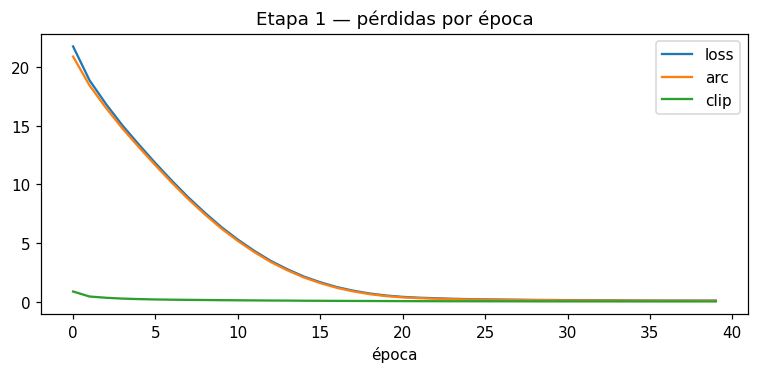

In [18]:
CKPT_CLIP = os.path.join(CFG.out_dir, "fashion_clip.pt")

history = []
for epoch in range(1, CFG.epochs_stage1 + 1):
    stats = train_one_epoch_stage1(model, train_loader, optimizer, scheduler, scaler, epoch)
    print(f"Epoch {epoch}: {stats}")
    history.append(stats)
    torch.save(unwrap(model).state_dict(), CKPT_CLIP)

pd.DataFrame(history).plot(figsize=(7, 3.5), title="Etapa 1 — pérdidas por época", xlabel="época")
plt.tight_layout(); plt.show()

## Part 3.5 — Retrieval evaluation

Two families of metrics:

- **Threshold-based F1**: for each item, all neighbors with a cosine similarity above the threshold are retrieved, and the predicted set is compared against the actual `label_group`. This measures clustering, not search.
- **Text-to-image Recall@K**: the product description is used as a query against the entire validation catalog. `R@K_item` requires retrieving that specific product; `R@K_group` accepts any product belonging to the same `label_group`. This is the metric that truly reflects natural language search.

In [19]:
@torch.no_grad()
def compute_embeddings(model, loader):
    model.eval()
    all_img, all_txt, all_pid, all_row = [], [], [], []
    for batch in tqdm(loader, desc="Calculando embeddings"):
        pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type="cuda"):
            img_e = unwrap(model).encode_image(pixel_values)
            txt_e = unwrap(model).encode_text(input_ids, attention_mask)
        all_img.append(img_e.float().cpu())
        all_txt.append(txt_e.float().cpu())
        all_pid.append(batch["pid"])
        all_row.append(batch["row"])
    return torch.cat(all_img), torch.cat(all_txt), torch.cat(all_pid).tolist(), torch.cat(all_row).tolist()

def chunked_matches(embeddings, threshold, chunk_size=2048):
    n = embeddings.size(0)
    matches = [None] * n
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        sim = embeddings[start:end] @ embeddings.t()
        for i in range(end - start):
            matches[start + i] = torch.where(sim[i] > threshold)[0].tolist()
    return matches

def f1_from_matches(pids, label_groups, matches):
    group2ids = {}
    for pid, g in zip(pids, label_groups):
        group2ids.setdefault(g, set()).add(pid)
    f1s = []
    for i, pid in enumerate(pids):
        true_set = group2ids[label_groups[i]]
        pred_set = {pids[j] for j in matches[i]}
        pred_set.add(pid)
        tp = len(true_set & pred_set)
        prec = tp / len(pred_set)
        rec = tp / len(true_set)
        f1s.append(2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0)
    return float(np.mean(f1s))

def search_best_threshold(embeddings, pids, label_groups, grid):
    start, stop, step = grid
    rows, best_thr, best_f1 = [], None, -1.0
    for thr in np.arange(start, stop, step):
        f1 = f1_from_matches(pids, label_groups, chunked_matches(embeddings, thr))
        rows.append({"threshold": round(float(thr), 3), "f1": f1})
        print(f"threshold={thr:.2f}  F1={f1:.4f}")
        if f1 > best_f1:
            best_thr, best_f1 = float(thr), f1
    return best_thr, best_f1, pd.DataFrame(rows)

In [20]:
def topk_text_to_image(txt_emb, img_emb, k=10, chunk=1024):
    outs = []
    for s in range(0, txt_emb.size(0), chunk):
        sim = txt_emb[s:s + chunk] @ img_emb.t()
        outs.append(sim.topk(k, dim=1).indices)
    return torch.cat(outs)

def recall_at_k(topk_idx, label_groups, ks=(1, 5, 10)):
    groups = np.asarray(label_groups)
    n = topk_idx.size(0)
    self_idx = torch.arange(n).unsqueeze(1)
    out = {}
    for k in ks:
        top = topk_idx[:, :k]
        out[f"R@{k}_item"] = (top == self_idx).any(dim=1).float().mean().item()
        neigh = groups[top.numpy()]
        out[f"R@{k}_group"] = float((neigh == groups[:, None]).any(axis=1).mean())
    return out

In [21]:
img_emb_raw, txt_emb_raw, val_pids, val_rows = compute_embeddings(model, val_loader)
val_order = val_df.iloc[val_rows].reset_index(drop=True)

img_emb = F.normalize(img_emb_raw, dim=-1)
txt_emb = F.normalize(txt_emb_raw, dim=-1)
val_groups = val_order["label_group"].tolist()
val_titles = val_order["productDisplayName"].tolist()

best_thr, best_f1, thr_table = search_best_threshold(img_emb, val_pids, val_groups, CFG.threshold_search_grid)
print(f"\nMejor threshold: {best_thr:.2f} | F1 validación: {best_f1:.4f}")

metrics = recall_at_k(topk_text_to_image(txt_emb, img_emb, k=10), val_groups)
print({k: round(v, 4) for k, v in metrics.items()})

Calculando embeddings:   0%|          | 0/70 [00:00<?, ?it/s]

threshold=0.30  F1=0.4358
threshold=0.35  F1=0.4768
threshold=0.40  F1=0.4928
threshold=0.45  F1=0.4865
threshold=0.50  F1=0.4667
threshold=0.55  F1=0.4412
threshold=0.60  F1=0.4147
threshold=0.65  F1=0.3893
threshold=0.70  F1=0.3681
threshold=0.75  F1=0.3547
threshold=0.80  F1=0.3468
threshold=0.85  F1=0.3415
threshold=0.90  F1=0.3392
threshold=0.95  F1=0.3384

Mejor threshold: 0.40 | F1 validación: 0.4928
{'R@1_item': 0.1488, 'R@1_group': 0.6825, 'R@5_item': 0.4053, 'R@5_group': 0.8862, 'R@10_item': 0.5536, 'R@10_group': 0.9319}


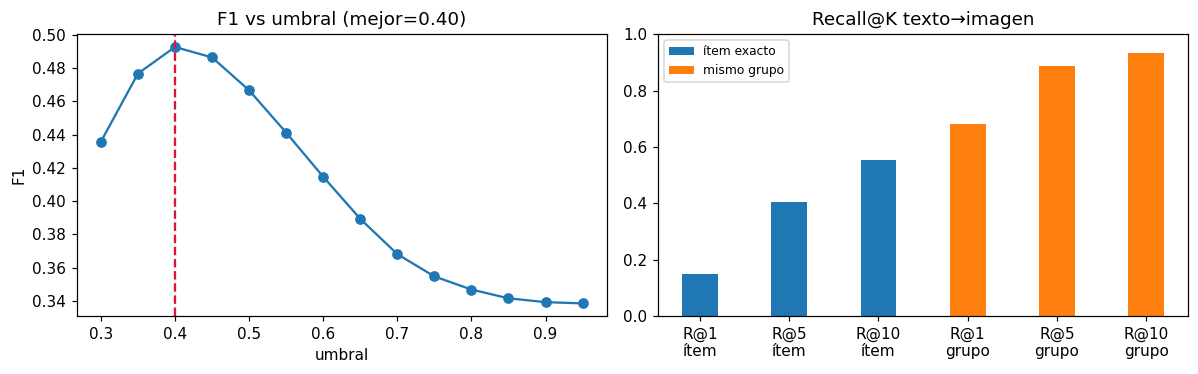

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(thr_table["threshold"], thr_table["f1"], marker="o")
axes[0].axvline(best_thr, color="crimson", ls="--")
axes[0].set_title(f"F1 vs umbral (mejor={best_thr:.2f})"); axes[0].set_xlabel("umbral"); axes[0].set_ylabel("F1")

ks = [1, 5, 10]
axes[1].bar([f"R@{k}\nítem" for k in ks], [metrics[f"R@{k}_item"] for k in ks], width=.4, label="ítem exacto")
axes[1].bar([f"R@{k}\ngrupo" for k in ks], [metrics[f"R@{k}_group"] for k in ks], width=.4, label="mismo grupo")
axes[1].set_ylim(0, 1); axes[1].set_title("Recall@K texto→imagen"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Part 3.6 — Natural language search

In [23]:
@torch.no_grad()
def encode_query(query: str):
    unwrap(model).eval()
    tok = clip_tokenizer(query, truncation=True, max_length=64, padding="max_length", return_tensors="pt")
    with torch.amp.autocast(device_type="cuda"):
        q = unwrap(model).encode_text(tok["input_ids"].to(DEVICE), tok["attention_mask"].to(DEVICE))
    return F.normalize(q, dim=-1).float().cpu()


def search_by_text(query, catalog_img_embeds, catalog_pids, catalog_titles, top_k=5):
    q = encode_query(query)
    sims = (catalog_img_embeds @ q.t()).squeeze(1)
    top = torch.topk(sims, k=min(top_k, sims.numel()))
    return [{"rank": i + 1, "id": catalog_pids[idx], "title": catalog_titles[idx], "score": round(score, 4),
             "catalog_idx": idx}
            for i, (score, idx) in enumerate(zip(top.values.tolist(), top.indices.tolist()))]

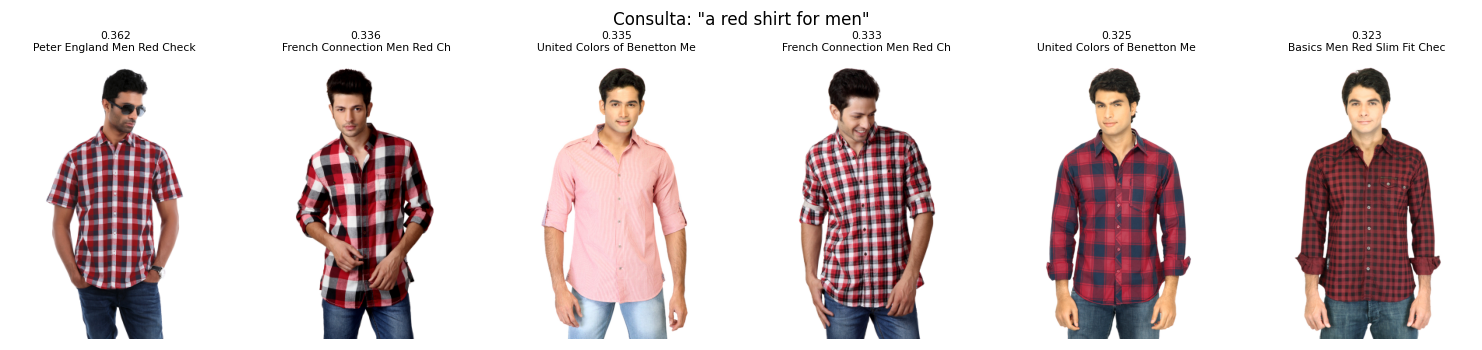

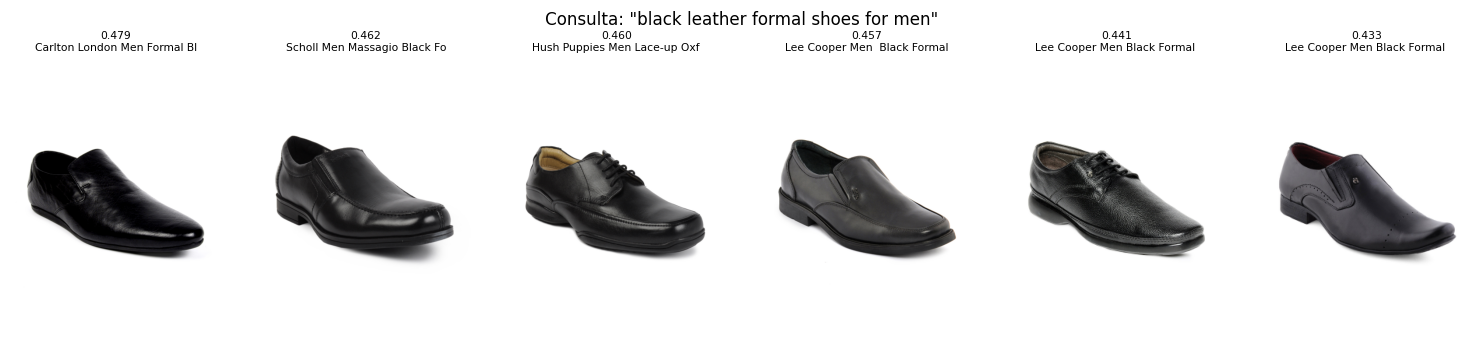

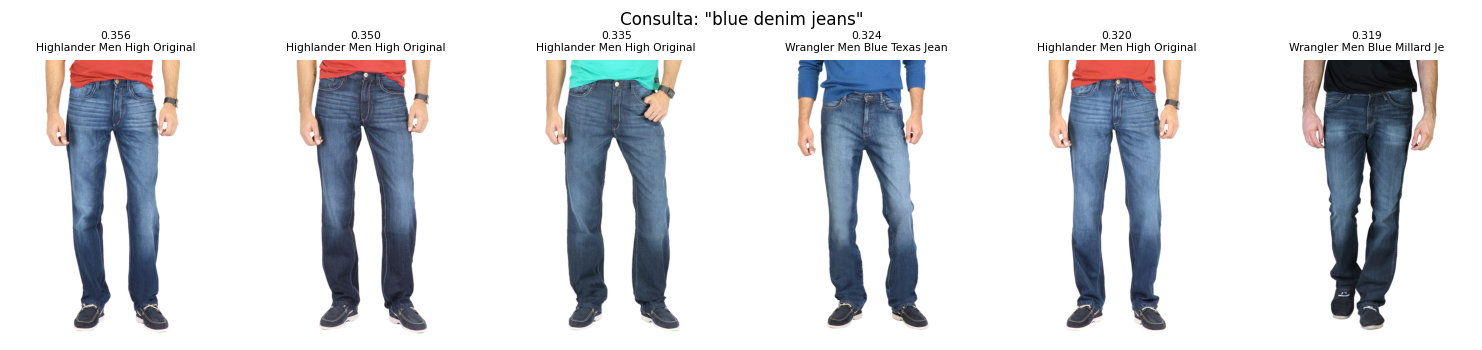

In [32]:
def show_results(query, top_k=6):
    results = search_by_text(query, img_emb, val_pids, val_titles, top_k=top_k)
    fig, axes = plt.subplots(1, top_k, figsize=(2.3 * top_k, 3.2))
    for ax, r in zip(np.atleast_1d(axes), results):
        ax.imshow(load_image(os.path.join(CFG.img_dir, f"{r['id']}.jpg"), 256))
        ax.set_title(f"{r['score']:.3f}\n{r['title'][:28]}", fontsize=7)
        ax.axis("off")
    fig.suptitle(f'Consulta: "{query}"', fontsize=11)
    plt.tight_layout(); plt.show()
    return results

for q in ["a red shirt for men", "black leather formal shoes for men", "blue denim jeans"]:
    show_results(q)

# Part 4 — 3D Visualization of the Embedding Space

Three views, each available in both static (matplotlib, with four camera angles) and interactive (plotly, with hover-over tooltips showing the actual product name) formats:

1. **Image embeddings** colored by `masterCategory` and `baseColour` — showing the semantic structure learned by ArcFace.
2. **Joint image-text space** — visual proof that the contrastive loss aligned the two modalities: if fine-tuning worked, each image-text pair appears close together, and the two point clouds overlap rather than separating into distinct clusters.
3. **A text query and its neighbors** — showing where a search vector lands within the catalog.

PCA is the default projection method (deterministic and computationally inexpensive); t-SNE separates clusters better but distorts global distances, so both options are provided.

The Plotly HTML files are saved in `/kaggle/working` and can be downloaded and opened outside the notebook.

In [ ]:
def project_3d(x, method="pca", seed=42, pre_dims=50):
    x = np.asarray(x, dtype=np.float32)
    if method == "pca":
        p = PCA(n_components=3, random_state=seed)
        coords = p.fit_transform(x)
        print("varianza explicada:", np.round(p.explained_variance_ratio_, 4), "| total:",
              round(float(p.explained_variance_ratio_.sum()), 4))
        return coords
    x = PCA(n_components=min(pre_dims, x.shape[1]), random_state=seed).fit_transform(x)
    return TSNE(n_components=3, init="pca", perplexity=30, learning_rate="auto",
                random_state=seed).fit_transform(x)


def plot_3d_matplotlib(coords, labels, title, fname, max_classes=12,
                       angles=((18, -60), (18, 30), (55, -45), (8, 125)), point_size=4):
    labels = pd.Series(labels).astype(str).values
    top = pd.Series(labels).value_counts().index[:max_classes].tolist()
    cmap = plt.get_cmap("tab20")
    palette = [cmap(k) for k in list(range(0, 20, 2)) + list(range(1, 20, 2))]
    fig = plt.figure(figsize=(13, 10))
    for i, (elev, azim) in enumerate(angles, 1):
        ax = fig.add_subplot(2, 2, i, projection="3d")
        for j, c in enumerate(top):
            m = labels == c
            ax.scatter(coords[m, 0], coords[m, 1], coords[m, 2], s=point_size, alpha=0.6,
                       color=palette[j % 20], linewidths=0, label=c if i == 1 else None)
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"elev={elev}  azim={azim}", fontsize=9)
        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    fig.suptitle(title, fontsize=13)
    handles, lab = fig.axes[0].get_legend_handles_labels()
    fig.legend(handles, lab, loc="lower center", ncol=6, fontsize=8, markerscale=3, frameon=False)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.08, wspace=0.0, hspace=0.08)
    fig.savefig(os.path.join(CFG.out_dir, fname), dpi=130)
    plt.show()


def plot_3d_plotly(coords, labels, hover, title, fname, point_size=2.6, opacity=0.75):
    d = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "z": coords[:, 2],
                      "label": pd.Series(labels).astype(str).values, "producto": hover})
    fig = px.scatter_3d(d, x="x", y="y", z="z", color="label", hover_name="producto",
                        opacity=opacity, title=title)
    fig.update_traces(marker=dict(size=point_size, line=dict(width=0)))
    fig.update_layout(height=780, legend=dict(itemsizing="constant", font=dict(size=9)),
                      scene=dict(xaxis_title="c1", yaxis_title="c2", zaxis_title="c3"),
                      margin=dict(l=0, r=0, t=40, b=0))
    fig.write_html(os.path.join(CFG.out_dir, fname))
    fig.show()
    return fig

In [ ]:
viz_n = min(CFG.viz_sample_size, len(val_order))
viz_idx = np.random.RandomState(42).choice(len(val_order), viz_n, replace=False)
viz_meta = val_order.iloc[viz_idx].reset_index(drop=True)
viz_img = img_emb[viz_idx].numpy()
viz_txt = txt_emb[viz_idx].numpy()
viz_hover = (viz_meta["productDisplayName"] + " · " + viz_meta["articleType"] + " · " + viz_meta["baseColour"]).tolist()
print("puntos a visualizar:", viz_n)

coords_img_pca = project_3d(viz_img, "pca")

In [ ]:
plot_3d_matplotlib(coords_img_pca, viz_meta["masterCategory"],
                   "Embeddings de imagen (PCA 3D) — por masterCategory", "emb3d_master_pca.png")

In [ ]:
plot_3d_plotly(coords_img_pca, viz_meta["masterCategory"], viz_hover,
               "Embeddings de imagen (PCA 3D) — masterCategory", "emb3d_master_pca.html")

In [ ]:
plot_3d_plotly(coords_img_pca, viz_meta["baseColour"], viz_hover,
               "Embeddings de imagen (PCA 3D) — baseColour", "emb3d_colour_pca.html")

In [ ]:
coords_img_tsne = project_3d(viz_img, "tsne")
plot_3d_matplotlib(coords_img_tsne, viz_meta["subCategory"],
                   "Embeddings de imagen (t-SNE 3D) — por subCategory", "emb3d_sub_tsne.png")
plot_3d_plotly(coords_img_tsne, viz_meta["subCategory"], viz_hover,
               "Embeddings de imagen (t-SNE 3D) — subCategory", "emb3d_sub_tsne.html")

In [ ]:
joint_n = min(1500, viz_n)
joint = np.concatenate([viz_img[:joint_n], viz_txt[:joint_n]], axis=0)
coords_joint = project_3d(joint, "pca")
modality = ["imagen"] * joint_n + ["texto"] * joint_n
joint_hover = viz_hover[:joint_n] * 2

plot_3d_matplotlib(coords_joint, modality,
                   "Espacio conjunto imagen + texto (PCA 3D)", "emb3d_joint_pca.png", point_size=3)

In [ ]:
fig = go.Figure()
for name, sl, color in [("imagen", slice(0, joint_n), "#2b6cb0"), ("texto", slice(joint_n, None), "#c05621")]:
    c = coords_joint[sl]
    fig.add_trace(go.Scatter3d(x=c[:, 0], y=c[:, 1], z=c[:, 2], mode="markers", name=name,
                               marker=dict(size=2.6, color=color, opacity=0.7),
                               text=viz_hover[:joint_n], hoverinfo="text+name"))

link_idx = np.random.RandomState(0).choice(joint_n, 60, replace=False)
for i in link_idx:
    a, b = coords_joint[i], coords_joint[joint_n + i]
    fig.add_trace(go.Scatter3d(x=[a[0], b[0]], y=[a[1], b[1]], z=[a[2], b[2]], mode="lines",
                               line=dict(color="rgba(120,120,120,0.55)", width=2),
                               showlegend=False, hoverinfo="skip"))

fig.update_layout(title="Alineación imagen↔texto (60 pares unidos por línea)", height=800,
                  margin=dict(l=0, r=0, t=40, b=0))
fig.write_html(os.path.join(CFG.out_dir, "emb3d_joint_pairs.html"))
fig.show()

pair_cos = (torch.from_numpy(viz_img) * torch.from_numpy(viz_txt)).sum(1)
rand_cos = (torch.from_numpy(viz_img) * torch.from_numpy(np.roll(viz_txt, 1, axis=0))).sum(1)
print(f"coseno medio par real: {pair_cos.mean():.4f} | par aleatorio: {rand_cos.mean():.4f}")

In [ ]:
def plot_query_3d(query, top_k=10, fname="emb3d_query.html"):
    q = encode_query(query).numpy()
    stacked = np.concatenate([viz_img, q], axis=0)
    coords = project_3d(stacked, "pca")
    cat_coords, q_coord = coords[:-1], coords[-1]

    sims = (torch.from_numpy(viz_img) @ torch.from_numpy(q).t()).squeeze(1)
    top = torch.topk(sims, top_k).indices.numpy()
    mask = np.zeros(len(viz_img), dtype=bool); mask[top] = True

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(x=cat_coords[~mask, 0], y=cat_coords[~mask, 1], z=cat_coords[~mask, 2],
                               mode="markers", name="catálogo",
                               marker=dict(size=2, color="#b0b7c3", opacity=0.45),
                               text=[h for h, m in zip(viz_hover, ~mask) if m], hoverinfo="text"))
    fig.add_trace(go.Scatter3d(x=cat_coords[mask, 0], y=cat_coords[mask, 1], z=cat_coords[mask, 2],
                               mode="markers", name=f"top-{top_k}",
                               marker=dict(size=6, color="#2f855a", opacity=0.95),
                               text=[viz_hover[i] for i in top], hoverinfo="text"))
    fig.add_trace(go.Scatter3d(x=[q_coord[0]], y=[q_coord[1]], z=[q_coord[2]], mode="markers+text",
                               name="consulta", marker=dict(size=9, color="#c53030", symbol="diamond"),
                               text=[query], textposition="top center"))
    for i in top:
        p = cat_coords[i]
        fig.add_trace(go.Scatter3d(x=[q_coord[0], p[0]], y=[q_coord[1], p[1]], z=[q_coord[2], p[2]],
                                   mode="lines", line=dict(color="rgba(47,133,90,0.5)", width=2),
                                   showlegend=False, hoverinfo="skip"))
    fig.update_layout(title=f'Consulta "{query}" y sus {top_k} vecinos', height=800,
                      margin=dict(l=0, r=0, t=40, b=0))
    fig.write_html(os.path.join(CFG.out_dir, fname))
    fig.show()

plot_query_3d("a red casual dress for women")

# Part 5 — Stage 2: Closed-vocabulary VQA

CLIP remains **frozen** here, so image embeddings do not change between epochs, they are computed once and reused. There are few unique questions (fixed templates + vocabulary negatives), so they are cached as well. Consequently, the stage trains on in-memory tensors, reducing epoch time from minutes to seconds and allowing for more epochs at no real cost. This follows the same principle as *Less Is More: Linear Layers on CLIP Features for Robust VQA*: the capacity lies in the backbone, while the head simply needs to fuse and classify.

The same cached image embeddings are reused in Stage 3.

## Part 5.1 — Embedding cache

In [ ]:
for p in model.parameters():
    p.requires_grad_(False)
model.eval()

@torch.no_grad()
def cache_image_embeddings(d, desc="cache"):
    ds = FashionRetrievalDataset(d, CFG.img_dir, eval_transform, clip_tokenizer, has_labels=False)
    ld = DataLoader(ds, batch_size=CFG.batch_size_stage1, shuffle=False,
                    num_workers=CFG.num_workers, pin_memory=True)
    outs = []
    for batch in tqdm(ld, desc=desc):
        with torch.amp.autocast(device_type="cuda"):
            e = unwrap(model).encode_image(batch["pixel_values"].to(DEVICE, non_blocking=True))
        outs.append(e.float().cpu())
    return torch.cat(outs)

@torch.no_grad()
def cache_text_embeddings(texts, max_len=32, bs=256, desc="cache texto"):
    uniq = sorted(set(texts))
    outs = []
    for i in tqdm(range(0, len(uniq), bs), desc=desc):
        tok = clip_tokenizer(uniq[i:i + bs], truncation=True, max_length=max_len,
                             padding="max_length", return_tensors="pt")
        with torch.amp.autocast(device_type="cuda"):
            e = unwrap(model).encode_text(tok["input_ids"].to(DEVICE), tok["attention_mask"].to(DEVICE))
        outs.append(e.float().cpu())
    return {q: i for i, q in enumerate(uniq)}, torch.cat(outs)

train_img_cache = cache_image_embeddings(train_df, "train image cache")
val_img_cache = cache_image_embeddings(val_df, "val image cache")
q2idx, q_cache = cache_text_embeddings(train_qa_df["question"].tolist() + val_qa_df["question"].tolist())
print(train_img_cache.shape, val_img_cache.shape, q_cache.shape, "| unique questions:", len(q2idx))

## Part 5.2 — Dataset and model

In [ ]:
def make_vqa_tensors(qa_df):
    return TensorDataset(
        torch.tensor(qa_df["row"].values, dtype=torch.long),
        torch.tensor([q2idx[q] for q in qa_df["question"]], dtype=torch.long),
        torch.tensor([ANSWER2IDX[a] for a in qa_df["answer"]], dtype=torch.long),
    )

vqa_train_loader = DataLoader(make_vqa_tensors(train_qa_df), batch_size=CFG.batch_size_stage2, shuffle=True)
vqa_val_loader   = DataLoader(make_vqa_tensors(val_qa_df), batch_size=CFG.batch_size_stage2, shuffle=False)

In [ ]:
# TODO: Test techniques that query image features, for example:
# Deep Cross-Attention (Cross-Attention / Perceiver / Flamingo)
# visual features directly into an LLM's input space, for example:
# Native VLMs (Vision-Language Models such as LLaVA, Qwen-VL, PaliGemma)
class VQAHead(nn.Module):
    def __init__(self, embed_dim, num_answers, hidden=1024, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embed_dim * 3),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 3, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.LayerNorm(hidden // 2),
            nn.Linear(hidden // 2, num_answers),
        )

    def forward(self, image_embeds, question_embeds):
        i = F.normalize(image_embeds, dim=-1)
        q = F.normalize(question_embeds, dim=-1)
        return self.net(torch.cat([i, q, i * q], dim=-1))

vqa_head = VQAHead(CFG.embed_dim, len(ANSWER_VOCAB)).to(DEVICE)
vqa_optimizer = torch.optim.AdamW(vqa_head.parameters(), lr=CFG.lr_stage2, weight_decay=1e-4)
vqa_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vqa_optimizer, T_max=CFG.epochs_stage2)
print(sum(p.numel() for p in vqa_head.parameters()) / 1e6, "M parameters in the VQA head")

## Part 5.3 — VQA Training

In [ ]:
GPU_TRAIN_IMG = train_img_cache.to(DEVICE)
GPU_VAL_IMG = val_img_cache.to(DEVICE)
GPU_Q = q_cache.to(DEVICE)

def run_epoch_stage2(loader, img_bank, train=True):
    vqa_head.train(train)
    total_loss, correct, n = 0.0, 0, 0
    for rows, qs, answers in loader:
        img = img_bank[rows.to(DEVICE)]
        q = GPU_Q[qs.to(DEVICE)]
        y = answers.to(DEVICE)
        with torch.set_grad_enabled(train):
            logits = vqa_head(img, q)
            loss = F.cross_entropy(logits, y, label_smoothing=0.05)
        if train:
            vqa_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            vqa_optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(-1) == y).sum().item()
        n += y.size(0)
    return total_loss / n, correct / n

vqa_history = []
for epoch in tqdm(range(1, CFG.epochs_stage2 + 1), desc="[Etapa 2]"):
    tr_loss, tr_acc = run_epoch_stage2(vqa_train_loader, GPU_TRAIN_IMG, True)
    with torch.no_grad():
        va_loss, va_acc = run_epoch_stage2(vqa_val_loader, GPU_VAL_IMG, False)
    vqa_scheduler.step()
    vqa_history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc, "val_acc": va_acc})
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_acc={va_acc:.4f}")

torch.save(vqa_head.state_dict(), os.path.join(CFG.out_dir, "vqa_head.pt"))
pd.DataFrame(vqa_history).set_index("epoch")[["train_acc", "val_acc"]].plot(
    figsize=(7, 3.5), title="Part 2 — VQA accuracy")
plt.tight_layout(); plt.show()

In [ ]:
@torch.no_grad()
def accuracy_by_qtype(qa_df, img_bank):
    vqa_head.eval()
    rows = torch.tensor(qa_df["row"].values, dtype=torch.long, device=DEVICE)
    qs = torch.tensor([q2idx[q] for q in qa_df["question"]], dtype=torch.long, device=DEVICE)
    y = torch.tensor([ANSWER2IDX[a] for a in qa_df["answer"]], dtype=torch.long, device=DEVICE)
    preds = []
    for s in range(0, len(rows), 4096):
        preds.append(vqa_head(img_bank[rows[s:s+4096]], GPU_Q[qs[s:s+4096]]).argmax(-1))
    preds = torch.cat(preds)
    out = qa_df.assign(ok=(preds == y).cpu().numpy())
    return out.groupby("qtype")["ok"].agg(["mean", "size"]).sort_values("mean", ascending=False)

acc_table = accuracy_by_qtype(val_qa_df, GPU_VAL_IMG)
display(acc_table)
acc_table["mean"].plot.barh(figsize=(6, 3.5), title="Validation accuracy by question type")
plt.xlim(0, 1); plt.tight_layout(); plt.show()

# Part 6 — Stage 3: Generative description (ClipCap: CLIP + GPT-2)

A mapping network translates the image's CLIP embedding into a prefix of `prefix_len` embeddings that GPT-2 consumes as if they were initial tokens—this is the *ClipCap* architecture (Mokady, Hertz & Bermano, 2021). Since CLIP is frozen, this stage also runs using the cache from Part 5.1; it does not access the disk again.

The training caption is the enriched description from Part 2.2, not the raw `productDisplayName`, so the model learns to mention color, type, category, usage, and season in a single sentence.

## Part 6.1 — Dataset and model

In [ ]:
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained(CFG.gpt2_name)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2 = GPT2LMHeadModel.from_pretrained(CFG.gpt2_name).to(DEVICE)
GPT2_DIM = gpt2.config.n_embd

cap_idx = np.random.RandomState(42).choice(
    len(train_df), int(len(train_df) * CFG.subset_frac_stage3), replace=False)
cap_texts = [train_df["description"].iloc[i] + gpt2_tokenizer.eos_token for i in cap_idx]
cap_enc = gpt2_tokenizer(cap_texts, truncation=True, max_length=CFG.caption_max_len,
                         padding="max_length", return_tensors="pt")

cap_loader = DataLoader(
    TensorDataset(torch.tensor(cap_idx, dtype=torch.long), cap_enc["input_ids"], cap_enc["attention_mask"]),
    batch_size=CFG.batch_size_stage3, shuffle=True)
print("Training captions:", len(cap_idx))

In [ ]:
class MappingNetwork(nn.Module):
    def __init__(self, clip_dim, gpt_dim, prefix_len, hidden_mult=2):
        super().__init__()
        self.prefix_len = prefix_len
        self.gpt_dim = gpt_dim
        hidden = clip_dim * hidden_mult
        self.net = nn.Sequential(
            nn.Linear(clip_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, gpt_dim * prefix_len),
        )

    def forward(self, clip_embed):
        return self.net(clip_embed).view(-1, self.prefix_len, self.gpt_dim)

mapper = MappingNetwork(CFG.embed_dim, GPT2_DIM, CFG.prefix_len).to(DEVICE)

In [ ]:
def set_gpt2_trainable(gpt2, first_n, last_n):
    for p in gpt2.parameters():
        p.requires_grad_(False)
    total = len(gpt2.transformer.h)
    keep = set(range(first_n)) | set(range(total - last_n, total))
    for i, block in enumerate(gpt2.transformer.h):
        if i in keep:
            for p in block.parameters():
                p.requires_grad_(True)
    for p in gpt2.transformer.wte.parameters():
        p.requires_grad_(True)
    for p in gpt2.transformer.ln_f.parameters():
        p.requires_grad_(True)

set_gpt2_trainable(gpt2, CFG.unfreeze_first_n_blocks, CFG.unfreeze_last_n_blocks)
n_train = sum(p.numel() for p in gpt2.parameters() if p.requires_grad)
print(f"GPT-2 trainable: {n_train/1e6:.1f}M of {sum(p.numel() for p in gpt2.parameters())/1e6:.1f}M")

## Part 6.2 — ClipCap Training

In [ ]:
def train_one_epoch_stage3(loader, optimizer, epoch):
    mapper.train(); gpt2.train()
    total_loss, total_n = 0.0, 0
    pbar = tqdm(loader, desc=f"[Etap 3] Epoch {epoch}")
    for rows, caption_ids, caption_mask in pbar:
        caption_ids = caption_ids.to(DEVICE)
        caption_mask = caption_mask.to(DEVICE)
        clip_embed = GPU_TRAIN_IMG[rows.to(DEVICE)]
        B = caption_ids.size(0)

        prefix_embeds = mapper(clip_embed)
        caption_embeds = gpt2.transformer.wte(caption_ids)
        inputs_embeds = torch.cat([prefix_embeds, caption_embeds], dim=1)

        ignore = torch.full((B, CFG.prefix_len), -100, dtype=torch.long, device=DEVICE)
        labels = torch.cat([ignore, caption_ids.masked_fill(caption_mask == 0, -100)], dim=1)
        attn = torch.cat([torch.ones(B, CFG.prefix_len, device=DEVICE, dtype=caption_mask.dtype),
                          caption_mask], dim=1)

        loss = gpt2(inputs_embeds=inputs_embeds, attention_mask=attn, labels=labels).loss
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(mapper.parameters()) + [p for p in gpt2.parameters() if p.requires_grad], 1.0)
        optimizer.step()

        total_loss += loss.item() * B
        total_n += B
        pbar.set_postfix(loss=total_loss / total_n)
    return total_loss / total_n

cap_optimizer = torch.optim.AdamW(
    list(mapper.parameters()) + [p for p in gpt2.parameters() if p.requires_grad], lr=CFG.lr_stage3)

for epoch in range(1, CFG.epochs_stage3 + 1):
    loss = train_one_epoch_stage3(cap_loader, cap_optimizer, epoch)
    print(f"Epoch {epoch}: loss={loss:.4f}")

torch.save({"mapper": mapper.state_dict(), "gpt2": gpt2.state_dict()},
           os.path.join(CFG.out_dir, "captioner.pt"))

## Part 6.3 — Generation

In [ ]:
def top_p_sample(logits, top_p=0.9, temperature=1.0):
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_probs, dim=-1)
    cutoff = cum > top_p
    cutoff[..., 1:] = cutoff[..., :-1].clone()
    cutoff[..., 0] = False
    sorted_probs[cutoff] = 0.0
    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    return sorted_idx.gather(-1, torch.multinomial(sorted_probs, 1))

@torch.no_grad()
def generate_description(image=None, clip_embed=None, max_len=40, temperature=0.75, top_p=0.9):
    mapper.eval(); gpt2.eval()
    if clip_embed is None:
        pixel_values = eval_transform(image.convert("RGB")).unsqueeze(0).to(DEVICE)
        clip_embed = unwrap(model).encode_image(pixel_values).float()
    prefix = mapper(clip_embed.to(DEVICE))

    generated, inputs_embeds, past = [], prefix, None
    for _ in range(max_len):
        out = gpt2(inputs_embeds=inputs_embeds, past_key_values=past, use_cache=True)
        past = out.past_key_values
        nxt = top_p_sample(out.logits[:, -1, :], top_p=top_p, temperature=temperature)
        if nxt.item() == gpt2_tokenizer.eos_token_id:
            break
        generated.append(nxt.item())
        inputs_embeds = gpt2.transformer.wte(nxt)
    return gpt2_tokenizer.decode(generated, skip_special_tokens=True)

In [ ]:
sample_rows = np.random.RandomState(3).choice(len(val_df), 4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, i in zip(axes, sample_rows):
    row = val_df.iloc[i]
    ax.imshow(load_image(os.path.join(CFG.img_dir, row["image"]), 256))
    gen = generate_description(clip_embed=val_img_cache[i:i+1])
    ax.set_title(f"real: {row['productDisplayName'][:30]}\n\ngen: {gen[:70]}", fontsize=7)
    ax.axis("off")
plt.tight_layout(); plt.show()

# Part 7 — General test of the 3 models

`ask()` unifies the three stages: if it receives text, it searches the catalog. If it receives an image, it generates a description; and if a question is also provided, it answers it using VQA.

In [ ]:
@torch.no_grad()
def answer_question(image=None, clip_embed=None, question="What color is this product?", top_k=3):
    vqa_head.eval()
    if clip_embed is None:
        pixel_values = eval_transform(image.convert("RGB")).unsqueeze(0).to(DEVICE)
        clip_embed = unwrap(model).encode_image(pixel_values).float()
    tok = clip_tokenizer(question, truncation=True, max_length=32, padding="max_length", return_tensors="pt")
    q_embed = unwrap(model).encode_text(tok["input_ids"].to(DEVICE), tok["attention_mask"].to(DEVICE)).float()
    probs = F.softmax(vqa_head(clip_embed.to(DEVICE), q_embed), dim=-1).squeeze(0)
    top = torch.topk(probs, top_k)
    return [{"answer": IDX2ANSWER[i.item()], "confidence": round(p.item(), 3)}
            for p, i in zip(top.values, top.indices)]


def ask(query_text=None, image=None, question=None, top_k=5,
        catalog_img_embeds=None, catalog_pids=None, catalog_titles=None):
    if query_text is not None and image is None:
        catalog_img_embeds = img_emb if catalog_img_embeds is None else catalog_img_embeds
        catalog_pids = val_pids if catalog_pids is None else catalog_pids
        catalog_titles = val_titles if catalog_titles is None else catalog_titles
        return {"mode": "search", "query": query_text,
                "results": search_by_text(query_text, catalog_img_embeds, catalog_pids, catalog_titles, top_k)}

    if image is not None:
        resp = {"mode": "vqa_and_caption", "description": generate_description(image=image)}
        if question is not None:
            resp["question"] = question
            resp["answers_ranked"] = answer_question(image=image, question=question)
        return resp

    raise ValueError("Pass `query_text` (search) or `image` (VQA / description).")

In [ ]:
ask(query_text="women's silver earrings for a party", top_k=5)

In [ ]:
row = val_df.iloc[int(sample_rows[0])]
sample_img = load_image(os.path.join(CFG.img_dir, row["image"]), 512)

plt.figure(figsize=(3, 4)); plt.imshow(sample_img); plt.axis("off")
plt.title(row["productDisplayName"], fontsize=8); plt.show()

for q in ["What color is this product?", "What type of product is this?",
          "Who is this product for?", "Which season is this product for?",
          "Is this a watch?"]:
    print(f"{q:45s} -> {answer_question(image=sample_img, question=q)}")

In [ ]:
import io, requests

img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTdp6-yctk6dKZDkxO5W0_W7y-_FCNOkmRNKBKSrc2BbmSqvTnYY285A1A&s=10"
external_img = Image.open(io.BytesIO(requests.get(img_url, stream=True).content)).convert("RGB")

plt.figure(figsize=(3, 3)); plt.imshow(external_img); plt.axis("off"); plt.show()
ask(image=external_img, question="Is this a t-shirt?")

In [ ]:
summary = {
    "n_train": len(train_df), "n_val": len(val_df), "n_classes_arcface": NUM_CLASSES,
    "best_threshold": best_thr, "f1_val": round(best_f1, 4),
    **{k: round(v, 4) for k, v in metrics.items()},
    "vqa_val_acc": round(vqa_history[-1]["val_acc"], 4),
    "answer_vocab": len(ANSWER_VOCAB),
}
with open(os.path.join(CFG.out_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

torch.save({"img_emb": img_emb, "txt_emb": txt_emb, "pids": val_pids},
           os.path.join(CFG.out_dir, "val_embeddings.pt"))
print(json.dumps(summary, indent=2))
print(sorted(os.listdir(CFG.out_dir)))